In [2]:
!pip install datalab-client pyvo
!pip install /arc/home/calvin/chime-ffff-pz/
!pip install /arc/home/calvin/FRB/


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.1/156.1 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 24.8 MB/s eta 0:00:00a 0:00:01
Processing /arc/home/calvin/chime-ffff-pz
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 7.8 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.1/978.1 kB 34.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.9/378.9 kB 45.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 80.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.8/198.8 kB 155.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey
import numpy as np
import pandas as pd
from astropy.io import fits
import os
import matplotlib.pyplot as plt
from chime_ffff_pz.path import plotting
import requests

# Step 0:
Change directory

In [2]:
PATH_TO_KKO_HOST_PAPER = '/arc/home/calvin/kko_host_paper' # Change as you see fit.
PATH_TO_CHIME_FFFF_PZ = '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/'
csv = pd.read_csv(os.path.join(PATH_TO_KKO_HOST_PAPER,'data_products/KKO_bursts_full.csv'))
csv.set_index('chime_event_id',inplace=True)

# Start with `KKO_bursts_full.csv`
Download `gri` band data for each burst if you haven't done so

In [3]:
csv = pd.read_csv(os.path.join(PATH_TO_KKO_HOST_PAPER,'data_products/KKO_bursts_full.csv'))
csv.set_index('chime_event_id',inplace=True)
from chime_ffff_pz.path.plotting import get_image_table_panstarrs
for color in ['g','r','i']:
    gg = get_image_table_panstarrs(csv['ra'], csv['dec'], size=960, filters=color, format="fits", imagetypes="stack").to_pandas()
    gg.set_index('dec',inplace=True)
    for event_id in csv.index:
        url = gg['url'][csv['dec'].loc[event_id]]
        r = requests.get(url)
        fn = os.path.join(PATH_TO_KKO_HOST_PAPER,f"data_products/hg_images/{event_id}_{color}.fits")
        with open(fn,'wb') as f: 

            # Saving received content as a png file in 
            # binary format 

            # write the contents of the response (r.content) 
            # to a new file in binary mode. 
            f.write(r.content) 
        print(csv.loc[event_id]['TNS'],fn)

20230730A /arc/home/calvin/kko_host_paper/data_products/hg_images/306528286_g.fits



KeyboardInterrupt



In [4]:
def show_rgb(self, filename=None, interpolation='nearest',
             vertical_flip=False, horizontal_flip=False, flip=False,**imshow_kwargs):
    """
    Show a 3-color image instead of the FITS file data.

    Parameters
    ----------

    filename, optional
        The 3-color image should have exactly the same dimensions
        as the FITS file, and will be shown with exactly the same
        projection. If FITSFigure was initialized with an
        AVM-tagged RGB image, the filename is not needed here.

    vertical_flip : str, optional
        Whether to vertically flip the RGB image

    horizontal_flip : str, optional
        Whether to horizontally flip the RGB image
    """

    try:
        from PIL import Image
    except ImportError:
        try:
            import Image
        except ImportError:
            raise ImportError("The Python Imaging Library (PIL) is required to read in RGB images")

    if flip:
        log.warning("Note that show_rgb should now correctly flip RGB images, so the flip= argument is now deprecated. If you still need to flip an image vertically or horizontally, you can use the vertical_flip= and horizontal_flip arguments instead.")

    if filename is None:
        if hasattr(self, '_rgb_image'):
            image = Image.open(self._rgb_image)
        else:
            raise Exception("Need to specify the filename of an RGB image")
    else:
        image = Image.open(filename)

    if vertical_flip:
        image = image.transpose(Image.FLIP_TOP_BOTTOM)

    if horizontal_flip:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)
    self.image = self.ax.imshow(image,
                                interpolation=interpolation,
                                origin='lower',**imshow_kwargs)


In [110]:
import os

from io import BytesIO
from io import StringIO
import requests
from PIL import Image

import numpy as np
import pandas

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)

import aplpy

from reproject.mosaicking import find_optimal_celestial_wcs
from reproject import reproject_interp
from reproject.mosaicking import reproject_and_coadd

from astropy.coordinates import SkyCoord, angular_separation
from astropy import units 
from astropy.table import Table, vstack, unique
from astropy.io import fits
from astropy import utils as astropy_utils
import astropy.units as u

from frb.surveys import survey_utils

from IPython import embed

def path_plot_kko_paper(
    sup_fig,
    subplot_idx,
    frb_name, # Name of the FRB
    cands, # CSV from chime-ffff-pz
    im_fits, # List containing three astropy.io.fits objects for R, G, B colors
    ra : float,
    a_err : float,
    dec : float,
    b_err : float,
    theta : float,
    size_arcmins : float = 0.5, # Size of image to query in arcmins
    P_Ox_thresh : float = 0.5, # A posterior threshold for declaring candidates "interesting" enough for including on the diagnostic plot
    outfile : str = None,
    stars = None,
    a = 1, # multiplicative constant outside of arcsinh
    b = 800 # multiplicative constant inside arcsinh argument
):
    """
    Create diagnostic plot for a PATH analysis
    
    Parameter
    ---------
    path_obj : astropy.table.Table 
        A table containing PATH results. Will have columns for:
        ra, dec, angular size of the host in arcseconds, r-band magnitude, P(O), P(O|x)
    ra : float
        Right ascension (degrees)
    a_err : float
        The semi-major axis in arcseconds
    dec : float
        Declination (degrees)
    b_err : float
        The semi-major axis in arcseconds
    theta : float
        Angle of the ellipse in degrees. The angle is defined as the angle of the
        semi-major axis, as degrees East from North
    dm : float
        The FRB dispersion measure in pc/cc
    gal_dm : float
        The Milky Way DM contribution for the given FRB
    size_arcmins : float
        Size of the image to query in arcminutes
    filt : float
        The optical filter to query for the image (should be one of "g", "r", "i", "z", "y")
    P_Ox_thresh : float
        A PATH posterior threshold for declaring candidates "interesting" enough for 
        including on the diagnostic plot.
    outfile : str
        File path/filename where the PATH results will be output. Should be a .png file
    survey_str : str
        A string indicating which survey to run the PATH analysis on, should be
        'Pan-STARRS' or 'DECaL' (Dark Energy Legacy Survey). Pan-STARRS is shallower,
        to a depth of rmag ~ 23. DECaL is deeper, with a depth of rmag ~ 24. So DECaL
        is preferred, but it is not always available (only covers ~1/2 of the CHIME FOV)
        
    Return
    ------
    Path : astropy.table.Table 
        A table containing PATH results. Will have columns for:
        ra, dec, angular size of the host in arcseconds, r-band magnitude, P(O), P(O|x)
    Will output the image to a png file in outfile
    """
    size_pixels = int(size_arcmins * 60. / 0.25)
    
    interesting_cands = cands[cands['P_Ox'] > P_Ox_thresh]
        
    print('Calculate an optimal WCS to share between all the fits')
    coord = SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')
    res = 0.25*u.arcsec
    wcs_out, shape_out = find_optimal_celestial_wcs(
                                                    im_fits,
                                                    resolution = res,
                                                    reference = coord,
                                                    )
    header_out = wcs_out.to_header()

    print('Generate empty datacube, reprojecting each color to the new WCS')
    image_cube = np.zeros((len(im_fits),) + shape_out, dtype=np.float32)
    for ii, im in enumerate(im_fits):
        array, footprint = reproject_interp(im, wcs_out, shape_out=shape_out)
        image_cube[ii, :, :] = array[:,::-1]
        
    output_fn = '{}_rgb_2d.fits'.format(frb_name)
    print('Write out collapsed version of cube for aplpy plotting purposes')
    fits.writeto(
        output_fn,
        np.nanmean(image_cube,axis = 0),
        header_out, 
        overwrite=True,
    )
    
    print('Save the reprojected fits into a PNG, also for aplpy plotting purposes')

    img = Image.fromarray(image_cube[0].astype(np.uint8))
    img.save(output_fn.replace('_2d.fits', '.png'))

    print('Make plot!')

    fig = aplpy.FITSFigure(output_fn, figure=sup_fig, subplot=subplot_idx)

    # scale rgb image cube; reorder axes; apply arcsinh
    import scipy.stats as sps
    image_cube[0] /= sps.median_abs_deviation(image_cube[0],nan_policy='omit')
    image_cube[1] /= sps.median_abs_deviation(image_cube[1],nan_policy='omit')
    image_cube[2] /= sps.median_abs_deviation(image_cube[2],nan_policy='omit')
    image_cube = np.moveaxis(image_cube,0,-1)

    fig.ax.imshow(a* np.fliplr(np.arcsinh(np.sum(image_cube,axis=-1) * b)))
    fig.add_label(x = 0.05,y=0.95,relative=True,text=frb_name,color = 'white',size=20,horizontalalignment='left',verticalalignment='top')
    #show_rgb(fig,output_fn.replace('_2d.fits', '.png'),**imshow_kwargs)
    #fig.set_nan_color('black')
    fig.tick_labels.set_font(size=20)
    fig.axis_labels.set_font(size=20)
    # fig.set_title("{0} {1}-Filter Image for Event ID: {2}\nExcess DM: {3:.2f} pc/cc".format(survey_str, filt, event_id, dm-gal_dm), fontsize=20)
    fig.add_grid()
    fig.grid.set_color('white')
    fig.grid.set_alpha(0.5)
    fig.grid.set_linestyle('solid')
    fig.grid.set_linewidth(1)
    fig.show_markers(ra, dec, facecolor='white', marker='+', s=300, zorder=20)
    # Note: width and height parameters should be 2 times semi-major/minor axes
    rot = theta - 90
    fig.show_ellipses(ra, dec, 2.*a_err, 2.*b_err, angle=rot, edgecolor='white', lw=2)
    fig.show_ellipses(ra, dec, 2.*a_err*3, 2.*b_err*3, angle=rot, edgecolor='white', linestyle='dashed', lw=2)
    
    #fig.add_label(1.05, .9, "Path P(O|x)", color='black', size=20, relative=True, horizontalalignment='left', weight='bold')
    jj = 1
    offsets = []
    for ii, cand in interesting_cands.iterrows():
        ra_cand = cand['ra']
        dec_cand = cand['dec']
        if jj == 1:
            fig.show_markers(ra_cand, dec_cand, edgecolor='red', facecolor='none', marker='s', s=100, lw=1.5, label='Potential Hosts')
        else:
            fig.show_markers(ra_cand, dec_cand, edgecolor='red', facecolor='none', marker='s', s=100, lw=1.5)
        label_x_loc = ra_cand
        label_y_loc = dec_cand + 5./3600.
        fig.add_label(label_x_loc, label_y_loc, str(jj), color='red', size=15)
        #fig.add_label(1.05, .9-0.05*jj, "{0}\t\t{1:.3f}".format(jj,cand['P_Ox']), color='black', size=20, relative=True, horizontalalignment='left')
        jj = jj + 1
        coord_cand = SkyCoord(ra_cand, dec_cand, unit=(u.deg, u.deg), frame='icrs')
        offset = angular_separation(coord.ra.rad, coord.dec.rad, coord_cand.ra.rad, coord_cand.dec.rad) * 180. / np.pi # deg
        offsets.append(offset)
    
    # Adjustable final zoom into the localization region, but encompassing
    # any interesting sources
    print(np.array(offsets)*60*2, size_arcmins)
    zoom_width = np.nanmax([np.nanmax(offsets, initial=0)*60*2, size_arcmins])
    fig.recenter(ra, dec, width=zoom_width/60., height=zoom_width/60.)
    print(ra,dec)
    
    # Print any galaxies within zoomed region
    other_sources = cands[cands['P_Ox'] < P_Ox_thresh]
    jj_init = jj
    print("Plotting Galaxies: {}".format(len(other_sources)))
    galaxies_to_plot = []
    for ii, cand in other_sources.iterrows():
        ra_cand = cand['ra']
        dec_cand = cand['dec']
        if (ra_cand > ra + zoom_width/np.cos(dec*np.pi/180.)/60.) or (ra_cand < ra - zoom_width/np.cos(dec*np.pi/180.)/60.) or (dec_cand > dec + zoom_width/60.) or (dec_cand < dec - zoom_width/60.): 
            continue
        else:
            galaxies_to_plot.append([ra_cand, dec_cand])
    galaxies_to_plot = np.array(galaxies_to_plot)
    #fig.show_markers(galaxies_to_plot[:,0], galaxies_to_plot[:,1], facecolor='none',  edgecolor='xkcd:orange', marker='o', s=50, lw=1.5, label='Other Galaxies') # 
        
    jj = 1
    if stars is not None:
        # Print any stars within zoomed region
        stars_to_plot = []
        for ii, cand in enumerate(stars):
            ra_cand = cand['ra']
            dec_cand = cand['dec']
            if (ra_cand > ra + zoom_width/np.cos(dec*np.pi/180.)/60.) or (ra_cand < ra - zoom_width/np.cos(dec*np.pi/180.)/60.) or (dec_cand > dec + zoom_width/60.) or (dec_cand < dec - zoom_width/60.): 
                continue
            else:
                stars_to_plot.append([ra_cand, dec_cand])
        stars_to_plot = np.array(stars_to_plot)
        print("Plotting Stars: {}".format(len(stars_to_plot)))
        fig.show_markers(stars_to_plot[:,0], stars_to_plot[:,1], edgecolor='blue', facecolor='None', marker='D', s=50, lw=1.5, label='Stars') 

    if outfile is not None:
        plt.savefig(outfile, dpi=100, format="png", bbox_inches="tight")
    plt.close()
    return image_cube,fig


# Make big cutout

In [103]:
import json
sup_fig,axs = plt.subplots(figsize=(20,30),nrows = 6, ncols = 4)
sup_fig.subplots_adjust(hspace = 0, wspace = 0)

ii = 0
for event_id, burst in list(csv.iterrows()):
    ax = axs.flat[ii]
    frb_tns = 'FRB' + burst['TNS']
    try:
        hdul_g = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_g.fits'))[0]
        hdul_r = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_r.fits'))[0]
        hdul_i = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_i.fits'))[0]
        with open(f'/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/{frb_tns}/{frb_tns}_PATH_input.json') as f:
            eellipse = json.load(f)
        
        cc,ff = path_plot_kko_paper(
            sup_fig = sup_fig,
            subplot_idx = (6,4,ii+1),
            frb_name = frb_tns, # Name of the FRB
            cands = pd.read_csv(os.path.join(PATH_TO_CHIME_FFFF_PZ, f'data/PATH/{frb_tns}/{frb_tns}_PATH_candidates.csv')), # Path object with information about the localization
            im_fits = [hdul_g,hdul_r,hdul_i],
            ra =burst['ra'],
            a_err =eellipse['lparam']['a'] / 3600,
            dec =burst['dec'],
            b_err =eellipse['lparam']['b'] / 3600,
            theta =eellipse['lparam']['theta'],
            size_arcmins = 3, # Size of image to query in arcmins
            P_Ox_thresh = 0.5, # A posterior threshold for declaring candidates "interesting" enough for including on the diagnostic plot
            outfile = os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}.png'),
            stars = None,
            a = 1,
            b = 300
            )
        ff.remove_grid()
        ff.axis_labels.hide()
        ff.tick_labels.hide()
        ff.ticks.hide()
        ax.set_yticks([])
        ax.set_xticks([])
    except FileNotFoundError:
        print('No PATH run:',frb_tns)
    ii += 1
sup_fig.savefig(os.path.join(PATH_TO_KKO_HOST_PAPER,'figures/hg_images.pdf'),dpi = 100)

Calculate an optimal WCS to share between all the fits
Generate empty datacube, reprojecting each color to the new WCS


this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]


Write out collapsed version of cube for aplpy plotting purposes


/tmp/ipykernel_1597/1628692302.py:126: RuntimeWarning: Mean of empty slice
  np.nanmean(image_cube,axis = 0),


Save the reprojected fits into a PNG, also for aplpy plotting purposes
Make plot!


...

Write out collapsed version of cube for aplpy plotting purposes


/tmp/ipykernel_1597/1628692302.py:126: RuntimeWarning: Mean of empty slice
  np.nanmean(image_cube,axis = 0),


Save the reprojected fits into a PNG, also for aplpy plotting purposes
Make plot!


/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/core.py:1176: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  s = self.ax.scatter(xw, yw, transform=self.ax.get_transform(coords_frame), **kwargs)


[0.92429772] 3
148.5490301 61.1478697
Plotting Galaxies: 219


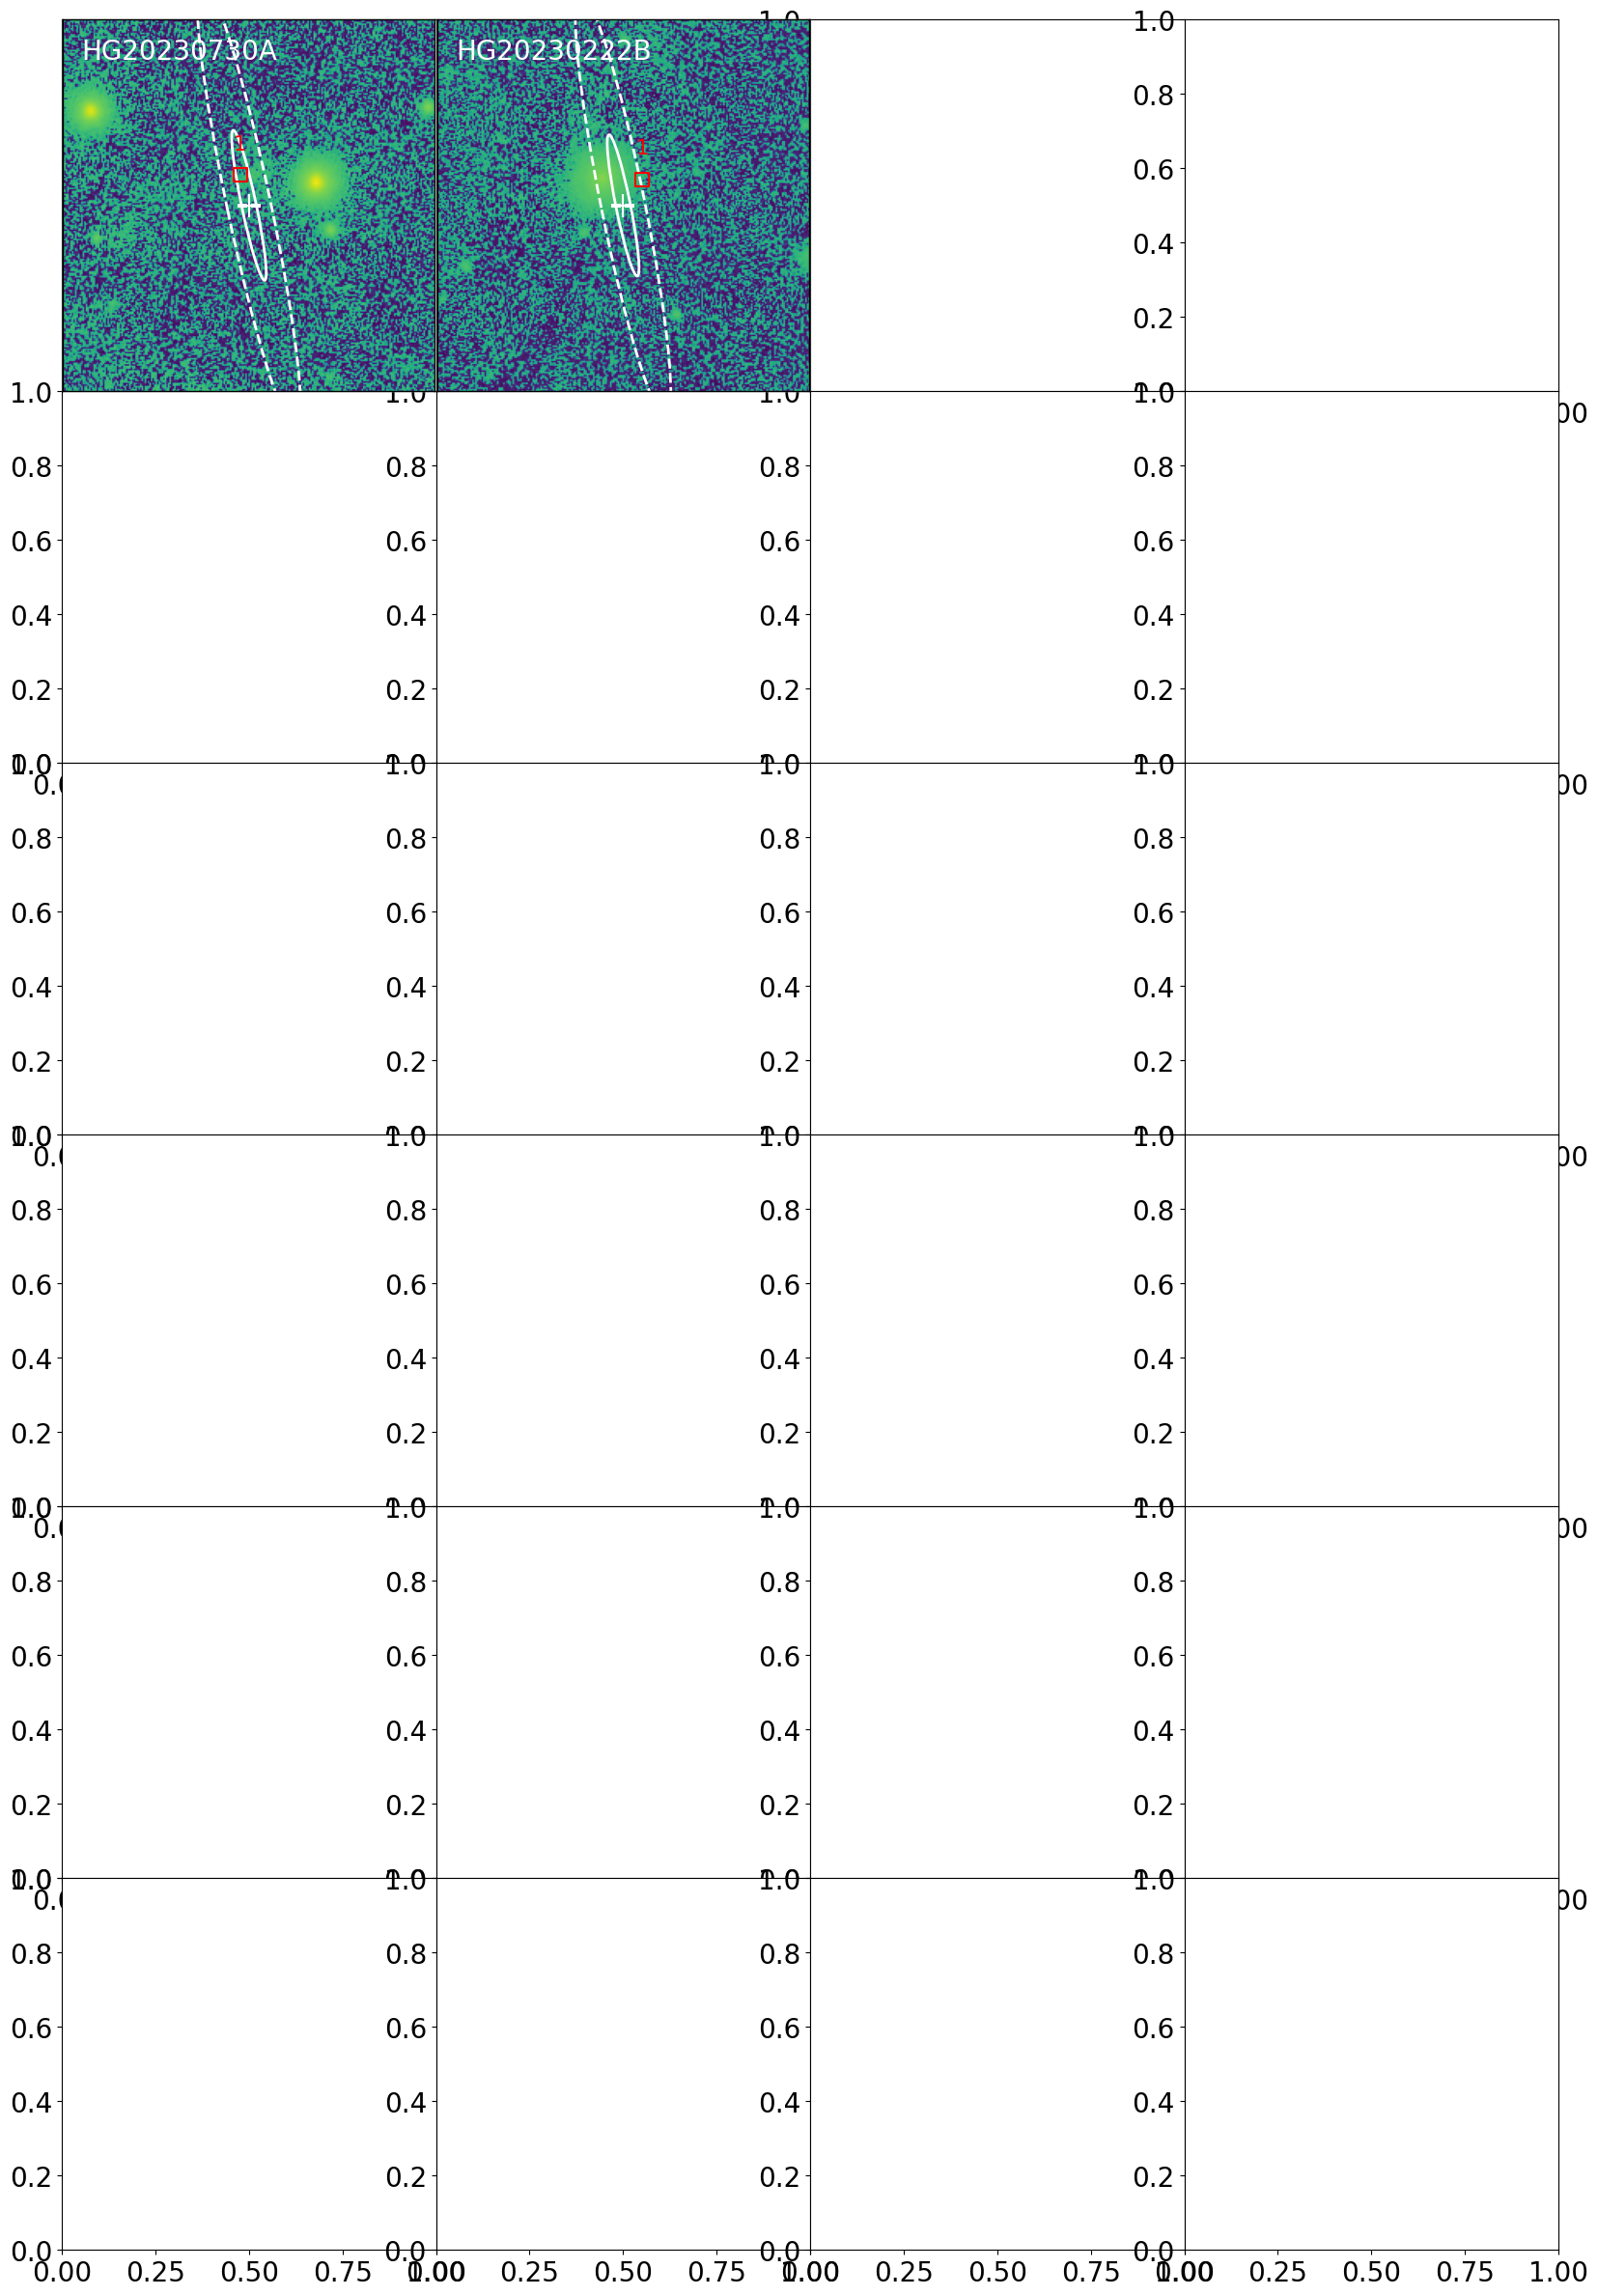

In [111]:
sup_fig

# Make zoom in cutout

In [ ]:
import json
sup_fig,axs = plt.subplots(figsize=(20,30),nrows = 6, ncols = 4)
sup_fig.subplots_adjust(hspace = 0, wspace = 0)
ii = 0
for event_id, burst in list(csv.iterrows()):
    ax = axs.flat[ii]
    frb_tns = 'FRB' + burst['TNS']
    hg_name = 'HG' + burst['TNS']
    try:
        hdul_g = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_g.fits'))[0]
        hdul_r = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_r.fits'))[0]
        hdul_i = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_i.fits'))[0]
        with open(f'/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/{frb_tns}/{frb_tns}_PATH_input.json') as f:
            eellipse = json.load(f)
        
        cc,ff = path_plot_kko_paper(
            sup_fig = sup_fig,
            subplot_idx = (6,4,ii+1),
            frb_name = hg_name, # Name of the FRB
            cands = pd.read_csv(os.path.join(PATH_TO_CHIME_FFFF_PZ, f'data/PATH/{frb_tns}/{frb_tns}_PATH_candidates.csv')), # Path object with information about the localization
            im_fits = [hdul_g,hdul_r,hdul_i],
            ra =burst['hg_primary_ra'],
            a_err = 10, #too big to see
            dec =burst['hg_primary_dec'],
            b_err = 10, #too big to see
            theta =eellipse['lparam']['theta'],
            size_arcmins = 0.5, # Size of image to query in arcmins
            P_Ox_thresh = 0.5, # A posterior threshold for declaring candidates "interesting" enough for including on the diagnostic plot
            outfile = os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}.png'),
            stars = None,
            a = 1,
            b = 300
        )
        ff.remove_grid()
        ff.axis_labels.hide()
        ff.tick_labels.hide()
        ff.ticks.hide()
        ax.set_yticks([])
        ax.set_xticks([])
    except FileNotFoundError:
        print('No PATH run:',frb_tns)
    ii += 1
sup_fig.savefig(os.path.join(PATH_TO_KKO_HOST_PAPER,'figures/hg_images_zoom.pdf'),dpi = 100)

Calculate an optimal WCS to share between all the fits
Generate empty datacube, reprojecting each color to the new WCS


this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]


Write out collapsed version of cube for aplpy plotting purposes
Save the reprojected fits into a PNG, also for aplpy plotting purposes


/tmp/ipykernel_1597/1024231700.py:126: RuntimeWarning: Mean of empty slice
  np.nanmean(image_cube,axis = 0),


Make plot!


...

/tmp/ipykernel_1597/1024231700.py:126: RuntimeWarning: Mean of empty slice
  np.nanmean(image_cube,axis = 0),


Make plot!


/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/core.py:1176: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  s = self.ax.scatter(xw, yw, transform=self.ax.get_transform(coords_frame), **kwargs)


[0.15773742] 0.5
106.96001895 11.22410689
Plotting Galaxies: 63
Calculate an optimal WCS to share between all the fits
Generate empty datacube, reprojecting each color to the new WCS


this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]


In [ ]:
sup_fig